In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [41]:
X, _ = make_blobs(n_samples=500,centers=3,cluster_std=1.5,random_state=42)

In [34]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(X)

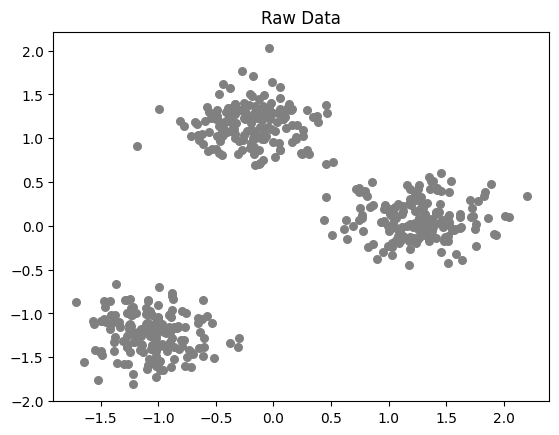

In [43]:
plt.scatter(x_scaled[:,0],x_scaled[:,1],s=30,c='gray',alpha=1)
plt.title("Raw Data")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(x_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [11]:
y_kmeans = kmeans.predict(x_scaled)

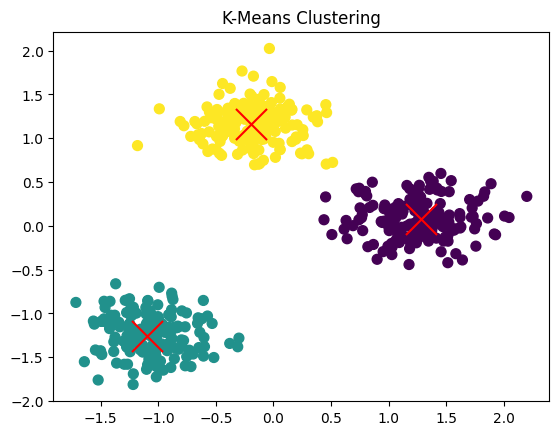

In [46]:
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=500, c='red', marker='x')  # Centroids
plt.title('K-Means Clustering')
plt.show()

In [14]:
print("Cluster Centroids:\n", kmeans.cluster_centers_)

Cluster Centroids:
 [[ 1.28325069  0.07843885]
 [-1.09315471 -1.25231533]
 [-0.19664182  1.16637758]]


In [47]:
from sklearn.cluster import DBSCAN

In [52]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
y_bscan = dbscan.fit_predict(x_scaled)

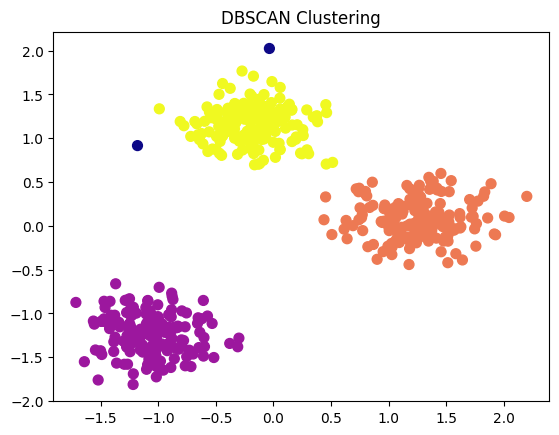

In [55]:
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_bscan, cmap='plasma', s=50)
plt.title('DBSCAN Clustering')
plt.show()

In [57]:
print("DBSCAN Cluster Labels:", np.unique(y_bscan))

DBSCAN Cluster Labels: [-1  0  1  2]


In [59]:
outliers = x_scaled[y_bscan == -1]
print(f"Number of outliers detected by DBSCAN: {len(outliers)}")

Number of outliers detected by DBSCAN: 2


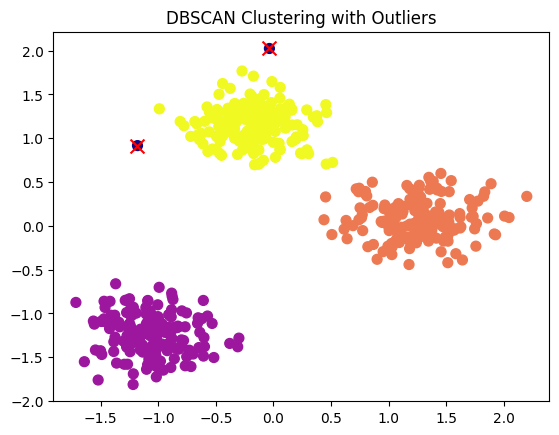

In [61]:
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_bscan, cmap='plasma', s=50)
plt.scatter(outliers[:, 0], outliers[:, 1], s=100, c='red', marker='x')  # Mark outliers
plt.title('DBSCAN Clustering with Outliers')
plt.show()